In [1]:
# Commented out IPython magic to ensure Python compatibility.
# 0. Setup
%pip install scikit-learn pandas matplotlib

try:
    from rdkit import Chem
    from rdkit.Chem import Draw, Descriptors, Crippen, rdMolDescriptors, AllChem
except Exception:
    try:
        %pip install rdkit
        from rdkit import Chem
        from rdkit.Chem import Draw, Descriptors, Crippen, rdMolDescriptors, AllChem
    except Exception as e:
        print("RDKit is not available in this environment. Drawing and descriptors will be skipped.")
        Chem = None


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", message="X has feature names")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 17.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import Crippen, Descriptors, Draw, Lipinski, rdFingerprintGenerator, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

sns.set_theme(style="whitegrid", context="notebook")


def mol_from_smiles(smiles):
    if pd.isna(smiles):
        return None
    return Chem.MolFromSmiles(str(smiles).strip())


def canonical_smiles(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)


def scaffold_smiles(mol):
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)


def descriptor_record(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        "canonical_smiles": canonical_smiles(smiles),
        "scaffold": scaffold_smiles(mol),
    }


def build_esol_features():
    raw = pd.read_csv("https://raw.githubusercontent.com/qckb/Data-course/main/esol.csv")

    rows = []
    for row_id, row in raw.reset_index(drop=True).iterrows():
        desc = descriptor_record(row["smiles"])
        if desc is None:
            continue
        desc.update(
            {
                "row_id": row_id,
                "smiles": str(row["smiles"]).strip(),
                "logS": float(row["log solubility (mol/L)"]),
            }
        )
        rows.append(desc)
    return pd.DataFrame(rows)


def fingerprint_array(smiles, n_bits=1024):
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
    matrix = np.zeros((len(smiles), n_bits), dtype=np.int8)
    for idx, smi in enumerate(smiles):
        fp = generator.GetFingerprint(mol_from_smiles(smi))
        DataStructs.ConvertToNumpyArray(fp, matrix[idx])
    return matrix


DESCRIPTOR_COLUMNS = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "AromaticRings",
    "FractionCSP3",
    "HeavyAtomCount",
]

In [3]:
examples = pd.read_csv("https://raw.githubusercontent.com/qckb/Data-course/main/example_molecules.csv")
examples = examples[examples["smiles"].apply(lambda s: mol_from_smiles(s) is not None)].reset_index(drop=True)

# This cell converts each example SMILES into interpretable descriptors.
# Inspect descriptors first so that "molecules become numbers" is grounded in readable chemical quantities.
descriptor_rows = []
for _, row in examples.iterrows():
    desc = descriptor_record(row["smiles"])
    desc.update({"name": row["name"], "smiles": row["smiles"]})
    descriptor_rows.append(desc)

desc_table = pd.DataFrame(descriptor_rows)
desc_table[["name", "MolWt", "MolLogP", "TPSA", "HBD", "HBA", "RingCount", "canonical_smiles"]].round(2)

[18:02:58] SMILES Parse Error: unclosed ring for input: 'C1CC'


,name,MolWt,MolLogP,TPSA,HBD,HBA,RingCount,canonical_smiles
0,ethanol,46.07,-0.00,20.23,1,1,0,CCO
1,benzene,78.11,1.69,0.00,0,0,1,c1ccccc1
2,toluene,92.14,2.00,0.00,0,0,1,Cc1ccccc1
3,aspirin,180.16,1.31,63.60,1,3,1,CC(=O)Oc1ccccc1C(=O)O
4,ibuprofen,206.28,3.07,37.30,1,1,1,CC(C)Cc1ccc(C(C)C(=O)O)cc1
5,glucose,180.16,-3.22,110.38,5,6,1,OC[C@H]1O[C@@H](O)[C@H](O)[C@@H](O)[C@H]1O
6,caffeine,194.19,-1.03,61.82,0,3,2,Cn1c(=O)c2c(ncn2C)n(C)c1=O


In [4]:
# radius controls the local environment size; fpSize controls the number of compressed bits.
generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fps = [generator.GetFingerprint(mol_from_smiles(smi)) for smi in examples["smiles"]]

# sim[i, j] is the Tanimoto similarity between molecule i and molecule j.
sim = np.zeros((len(fps), len(fps)))
for i, fp_i in enumerate(fps):
    for j, fp_j in enumerate(fps):
        sim[i, j] = DataStructs.FingerprintSimilarity(fp_i, fp_j)

sim_df = pd.DataFrame(sim, index=examples["name"], columns=examples["name"])
sim_df.round(2)

name,ethanol,benzene,toluene,aspirin,ibuprofen,glucose,caffeine
name,,,,,,,
ethanol,1.00,0.00,0.06,0.11,0.11,0.15,0.03
benzene,0.00,1.00,0.27,0.12,0.08,0.00,0.04
toluene,0.06,0.27,1.00,0.25,0.16,0.00,0.09
aspirin,0.11,0.12,0.25,1.00,0.20,0.02,0.09
ibuprofen,0.11,0.08,0.16,0.20,1.00,0.11,0.11
glucose,0.15,0.00,0.00,0.02,0.11,1.00,0.02
caffeine,0.03,0.04,0.09,0.09,0.11,0.02,1.00


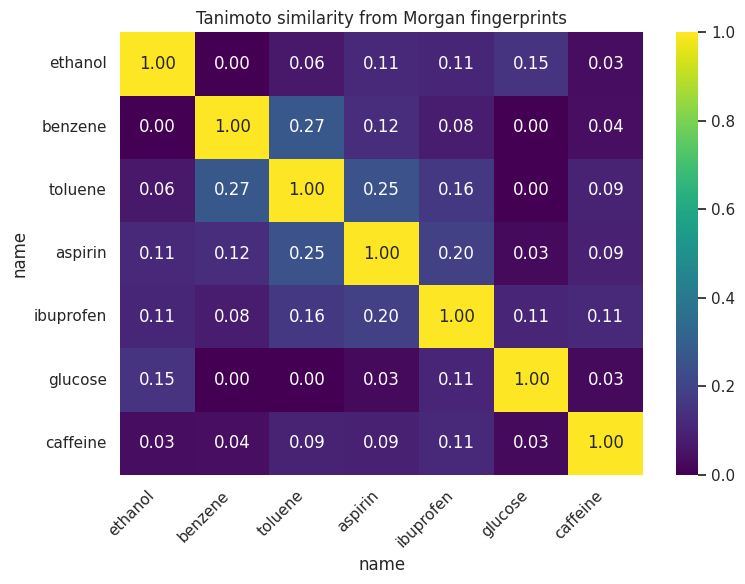

In [5]:
# The heatmap shows the similarity matrix; the diagonal is 1 because each molecule is identical to itself.
plt.figure(figsize=(8, 6))
sns.heatmap(sim_df, vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f")
plt.title("Tanimoto similarity from Morgan fingerprints")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

('benzene', 'toluene') Tanimoto = 0.273


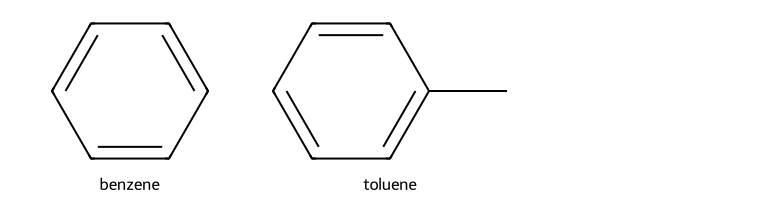

In [6]:
pair = ("benzene", "toluene")  # try ("ethanol", "glucose") or ("aspirin", "ibuprofen")
idx_a = examples.index[examples["name"] == pair[0]][0]
idx_b = examples.index[examples["name"] == pair[1]][0]

# Change pair to quickly compare numerical similarity with chemical intuition.
print(pair, "Tanimoto =", sim[idx_a, idx_b].round(3))
Draw.MolsToGridImage(
    [mol_from_smiles(examples.loc[idx_a, "smiles"]), mol_from_smiles(examples.loc[idx_b, "smiles"])],
    legends=list(pair),
    subImgSize=(260, 200),
)

# Questions

1. Does the similarity between benzene and toluene match your intuition?

2. Which descriptor seems most connected to aqueous solubility?

3. Fingerprint bits are not very intuitive one by one. Why are they still useful?